# Histogram-Band Curriculum

Iteratively search the same batch of colorings while widening the permitted structural emphasis from H5-only to unrestricted H0–H10. A stage ends when its best structurally allowed action would increase the Ramsey score, or when it reaches the maximum step count. Zero-reward moves remain allowed because they can reorganize structure without sacrificing score. The minimum-observed coloring becomes that coloring's seed for the next stage.

In [1]:
# Experiment Configuration

RANDOM_SEED = 202_608_082
N_VERTICES = 43
NUMBER_OF_COLORINGS = 100

H_BANDS = (
    (5, 5),
    (4, 6),
    (3, 7),
    (2, 8),
    (1, 9),
    (0, 10),
)

MAXIMUM_STAGE_STEPS = 256
MINIMUM_ALLOWED_REWARD = 0

EDGE_TABU_TENURE = 20
VISITED_STATE_WINDOW = 2_000

REPORT_EVERY_COLORINGS = 10
RUN_NAME = "histogram-band-curriculum-001"
DATABASE_FILENAME = "histogram_band_curriculum.sqlite3"

In [2]:
# Imports and Project Root

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from ramsey import (
    REnvironment,
    REnvironmentConfig,
    RGraph,
    RHistogramBandGreedyPolicy,
    RHistogramBandPolicyConfig,
    RMonochromaticObjective,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
    RTabuMemory,
    RTabuMemoryConfig,
)

project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

if not (project_root / "ramsey").is_dir():
    raise RuntimeError(
        "Run this notebook from the RamseyNumber root "
        "or notebooks directory."
    )

DATABASE_PATH = (
    project_root
    / "data"
    / "experiments"
    / DATABASE_FILENAME
)

In [3]:
# Graph and Initial Random Batch

construction_rng = np.random.default_rng(RANDOM_SEED)
graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
construction = RRandomConstruction(construction_rng)

current_colorings = [
    construction.construct(graph)
    for _ in range(NUMBER_OF_COLORINGS)
]

print("Edges:", f"{graph.number_of_edges:,}")
print("K5s:", f"{graph.subgraph_index(5).clique_count:,}")
print("Colorings:", NUMBER_OF_COLORINGS)
print("Stages:", H_BANDS)
print("Structural pool: above-average H-band load")
print("Maximum steps per stage:", MAXIMUM_STAGE_STEPS)
print("Minimum allowed exact reward:", MINIMUM_ALLOWED_REWARD)
print("Database:", DATABASE_PATH.resolve())

Edges: 903
K5s: 962,598
Colorings: 100
Stages: ((5, 5), (4, 6), (3, 7), (2, 8), (1, 9), (0, 10))
Structural pool: above-average H-band load
Maximum steps per stage: 256
Minimum allowed exact reward: 0
Database: C:\code\RamseyNumber\data\experiments\histogram_band_curriculum.sqlite3


In [4]:
# One Curriculum Stage for One Coloring

def run_stage(seed_coloring, h_min, h_max, rng):
    environment = REnvironment(
        graph=graph,
        objective=RMonochromaticObjective(),
        memory=RTabuMemory(
            graph.number_of_edges,
            RTabuMemoryConfig(
                edge_tenure=EDGE_TABU_TENURE,
                visited_state_window=VISITED_STATE_WINDOW,
            ),
        ),
        config=REnvironmentConfig(
            max_steps=MAXIMUM_STAGE_STEPS,
        ),
    )

    environment.reset(seed_coloring)

    policy = RHistogramBandGreedyPolicy(
        rng=rng,
        config=RHistogramBandPolicyConfig(
            h_min=h_min,
            h_max=h_max,
            candidate_pool_size=None,
        ),
    )

    initial_score = environment.state.score
    trajectory = [initial_score]
    allowed_reward_trajectory = []
    reward_wall = False
    wall_reward = None

    while not (environment.terminated or environment.truncated):
        edge = policy.select_action(environment)
        allowed_reward = policy.last_decision.exact_reward
        allowed_reward_trajectory.append(allowed_reward)

        if allowed_reward < MINIMUM_ALLOWED_REWARD:
            reward_wall = True
            wall_reward = allowed_reward
            break

        result = environment.step(edge, full_analysis=True)
        trajectory.append(result.score)

    return {
        "h_min": h_min,
        "h_max": h_max,
        "initial_score": initial_score,
        "final_score": environment.state.score,
        "minimum_score": environment.best_score,
        "minimum_coloring": environment.best_coloring,
        "steps": environment.step_number,
        "reward_wall": reward_wall,
        "wall_reward": wall_reward,
        "trajectory": np.asarray(trajectory, dtype=np.int32),
        "allowed_reward_trajectory": np.asarray(
            allowed_reward_trajectory,
            dtype=np.int32,
        ),
    }

In [5]:
# Run the Curriculum

existing_archive = globals().get("archive")

if existing_archive is not None:
    existing_archive.close()

archive = RSQLiteArchive(DATABASE_PATH)
stage_summaries = []
all_stage_results = []
lineage = []
curriculum_start = perf_counter()

for stage_number, (h_min, h_max) in enumerate(H_BANDS):
    print()
    print(f"STAGE {stage_number}: H{h_min}–H{h_max}")
    print("-" * 48)

    next_colorings = []
    stage_results = []
    stage_start = perf_counter()

    for coloring_number, seed_coloring in enumerate(current_colorings):
        action_rng = np.random.default_rng(
            RANDOM_SEED
            + 100_000 * (stage_number + 1)
            + coloring_number
        )

        result = run_stage(
            seed_coloring,
            h_min,
            h_max,
            action_rng,
        )

        next_colorings.append(result["minimum_coloring"])
        stage_results.append(result)

        archive_record = archive.save_coloring(
            result["minimum_coloring"],
            run_name=(
                f"{RUN_NAME}-H{h_min}-H{h_max}"
            ),
            iteration=coloring_number,
        )

        lineage.append({
            "coloring": coloring_number,
            "stage": stage_number,
            "h_min": h_min,
            "h_max": h_max,
            "initial_score": result["initial_score"],
            "minimum_score": result["minimum_score"],
            "steps": result["steps"],
            "reward_wall": result["reward_wall"],
            "wall_reward": result["wall_reward"],
            "archive_id": archive_record.coloring_id,
        })

        completed = coloring_number + 1

        if (
            completed % REPORT_EVERY_COLORINGS == 0
            or completed == NUMBER_OF_COLORINGS
        ):
            recent = stage_results[-REPORT_EVERY_COLORINGS:]
            recent_minima = [r["minimum_score"] for r in recent]
            print(
                f"{completed:4d}/{NUMBER_OF_COLORINGS} | "
                f"recent mean min={np.mean(recent_minima):7.2f} | "
                f"recent min={min(recent_minima):4d}"
            )

    stage_elapsed = perf_counter() - stage_start
    initial = np.asarray(
        [r["initial_score"] for r in stage_results],
        dtype=np.int32,
    )
    minima = np.asarray(
        [r["minimum_score"] for r in stage_results],
        dtype=np.int32,
    )
    steps_taken = np.asarray(
        [r["steps"] for r in stage_results],
        dtype=np.int32,
    )
    reward_walls = sum(
        r["reward_wall"]
        for r in stage_results
    )

    summary = {
        "stage": stage_number,
        "band": f"H{h_min}–H{h_max}",
        "mean_initial": float(initial.mean()),
        "mean_minimum": float(minima.mean()),
        "median_minimum": float(np.median(minima)),
        "minimum": int(minima.min()),
        "mean_reduction": float((initial - minima).mean()),
        "mean_steps": float(steps_taken.mean()),
        "reward_walls": int(reward_walls),
        "elapsed": stage_elapsed,
    }
    stage_summaries.append(summary)
    all_stage_results.append(stage_results)
    current_colorings = next_colorings

    print(
        f"COMPLETE | mean initial={summary['mean_initial']:.2f} | "
        f"mean minimum={summary['mean_minimum']:.2f} | "
        f"minimum={summary['minimum']} | "
        f"mean reduction={summary['mean_reduction']:.2f} | "
        f"mean steps={summary['mean_steps']:.1f} | "
        f"reward walls={summary['reward_walls']}/{NUMBER_OF_COLORINGS} | "
        f"time={stage_elapsed:.1f}s"
    )

curriculum_elapsed = perf_counter() - curriculum_start


STAGE 0: H5–H5
------------------------------------------------
  10/100 | recent mean min= 351.80 | recent min= 297
  20/100 | recent mean min= 362.80 | recent min= 322
  30/100 | recent mean min= 337.80 | recent min= 287
  40/100 | recent mean min= 354.00 | recent min= 299
  50/100 | recent mean min= 364.60 | recent min= 328
  60/100 | recent mean min= 386.20 | recent min= 285
  70/100 | recent mean min= 367.30 | recent min= 311
  80/100 | recent mean min= 360.70 | recent min= 286
  90/100 | recent mean min= 365.90 | recent min= 320
 100/100 | recent mean min= 381.00 | recent min= 325
COMPLETE | mean initial=1886.93 | mean minimum=363.21 | minimum=285 | mean reduction=1523.72 | mean steps=229.9 | reward walls=80/100 | time=84.0s

STAGE 1: H4–H6
------------------------------------------------
  10/100 | recent mean min= 335.00 | recent min= 289
  20/100 | recent mean min= 334.60 | recent min= 295
  30/100 | recent mean min= 319.70 | recent min= 268
  40/100 | recent mean min= 326.80

In [6]:
# Final Report

print("HISTOGRAM-BAND CURRICULUM REPORT")
print()
print(
    "stage | band      | mean in | mean min | median | min | "
    "reduction | steps | walls"
)
print("------|-----------|---------|----------|--------|-----|-----------|-------|------")

for summary in stage_summaries:
    print(
        f"{summary['stage']:5d} | "
        f"{summary['band']:9s} | "
        f"{summary['mean_initial']:7.1f} | "
        f"{summary['mean_minimum']:8.1f} | "
        f"{summary['median_minimum']:6.1f} | "
        f"{summary['minimum']:3d} | "
        f"{summary['mean_reduction']:9.1f} | "
        f"{summary['mean_steps']:5.1f} | "
        f"{summary['reward_walls']:3d}/{NUMBER_OF_COLORINGS}"
    )

print()
print("Archive best:", archive.best_score(graph))
print("Total elapsed:", f"{curriculum_elapsed:.1f}s")

HISTOGRAM-BAND CURRICULUM REPORT

stage | band      | mean in | mean min | median | min | reduction | steps | walls
------|-----------|---------|----------|--------|-----|-----------|-------|------
    0 | H5–H5     |  1886.9 |    363.2 |  356.5 | 285 |    1523.7 | 229.9 |  80/100
    1 | H4–H6     |   363.2 |    339.3 |  331.5 | 268 |      23.9 |  28.0 | 100/100
    2 | H3–H7     |   339.3 |    327.2 |  321.0 | 260 |      12.2 |  18.0 | 100/100
    3 | H2–H8     |   327.2 |    305.5 |  296.0 | 243 |      21.6 |  25.4 | 100/100
    4 | H1–H9     |   305.5 |    302.7 |  294.5 | 241 |       2.8 |   6.4 | 100/100
    5 | H0–H10    |   302.7 |    237.2 |  235.5 | 201 |      65.5 |  51.4 | 100/100

Archive best: 201
Total elapsed: 224.0s


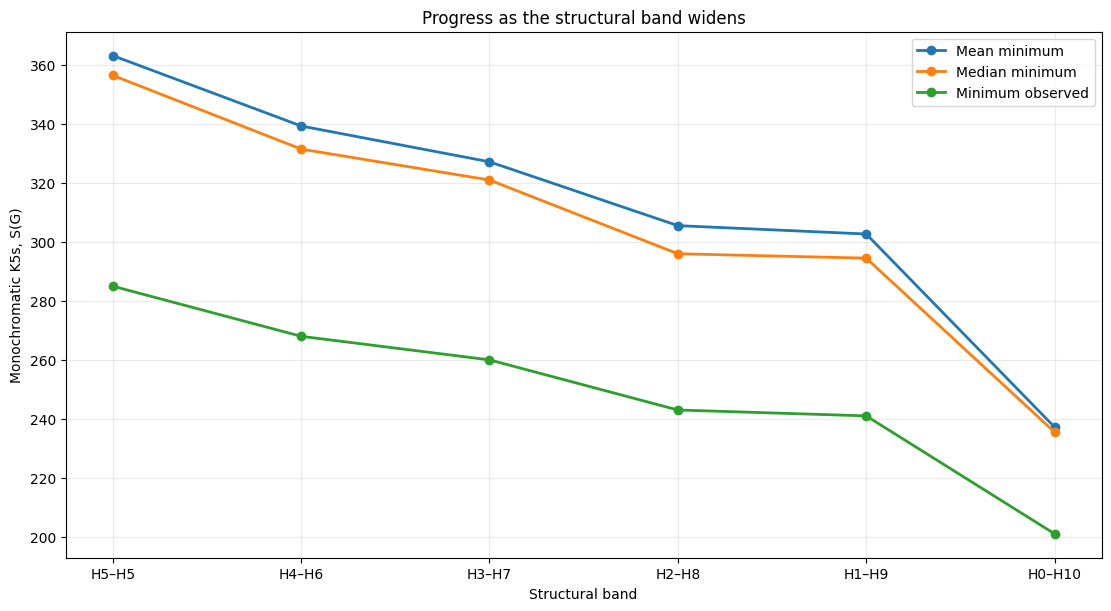

In [7]:
# Visualize Progress Through the Curriculum

labels = [summary["band"] for summary in stage_summaries]
mean_minima = [summary["mean_minimum"] for summary in stage_summaries]
median_minima = [summary["median_minimum"] for summary in stage_summaries]
absolute_minima = [summary["minimum"] for summary in stage_summaries]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
ax.plot(x, mean_minima, marker="o", linewidth=2, label="Mean minimum")
ax.plot(x, median_minima, marker="o", linewidth=2, label="Median minimum")
ax.plot(x, absolute_minima, marker="o", linewidth=2, label="Minimum observed")
ax.set_xticks(x, labels)
ax.set_xlabel("Structural band")
ax.set_ylabel("Monochromatic K5s, S(G)")
ax.set_title("Progress as the structural band widens")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

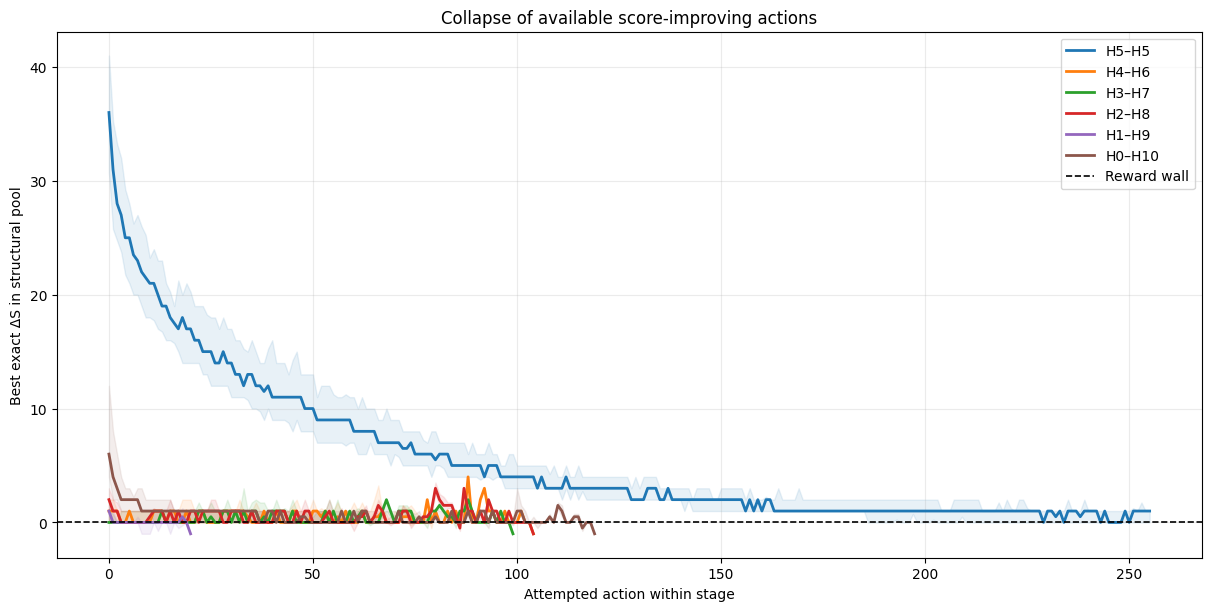

In [8]:
# Visualize the Allowed-Reward Landscape

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

for stage_number, stage_results in enumerate(all_stage_results):
    maximum_length = max(
        len(result["allowed_reward_trajectory"])
        for result in stage_results
    )

    reward_matrix = np.full(
        (len(stage_results), maximum_length),
        np.nan,
        dtype=np.float64,
    )

    for row, result in enumerate(stage_results):
        rewards = result["allowed_reward_trajectory"]
        reward_matrix[row, :len(rewards)] = rewards

    median_reward = np.nanmedian(reward_matrix, axis=0)
    q25_reward = np.nanpercentile(reward_matrix, 25, axis=0)
    q75_reward = np.nanpercentile(reward_matrix, 75, axis=0)
    reward_steps = np.arange(maximum_length)
    label = stage_summaries[stage_number]["band"]

    line = ax.plot(
        reward_steps,
        median_reward,
        linewidth=2,
        label=label,
    )[0]

    ax.fill_between(
        reward_steps,
        q25_reward,
        q75_reward,
        color=line.get_color(),
        alpha=0.10,
    )

ax.axhline(
    MINIMUM_ALLOWED_REWARD,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label="Reward wall",
)
ax.set_xlabel("Attempted action within stage")
ax.set_ylabel("Best exact ΔS in structural pool")
ax.set_title("Collapse of available score-improving actions")
ax.grid(alpha=0.25)
ax.legend()
plt.show()